2026-05-21 21:11:37.365381: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779397897.645341      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779397897.731293      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779397898.402383      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779397898.402427      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779397898.402430      57 computation_placer.cc:177] computation placer alr

Навчання FeedForward (10 нейронів)...
Навчання FeedForward (20 нейронів)...
Навчання Cascade (20 нейронів)...
Навчання Cascade (2x10 нейронів)...
Навчання Elman (15 нейронів)...
Навчання Elman (3x5 нейронів)...


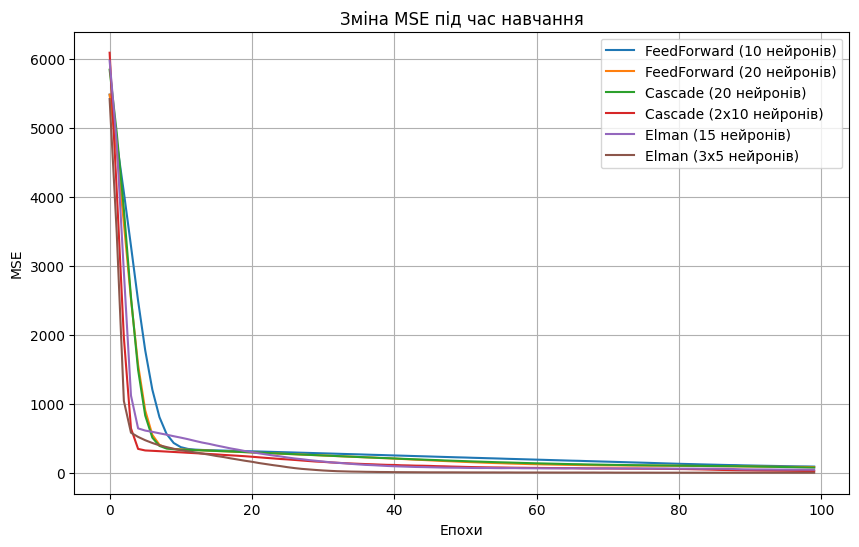

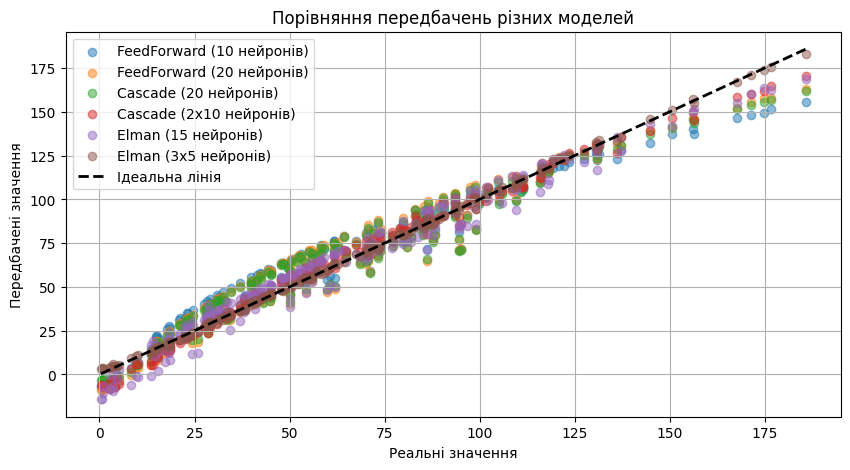


=== Результати дослідження ===
FeedForward (10 нейронів): середня відносна помилка = 0.4946, R² = 0.9426
FeedForward (20 нейронів): середня відносна помилка = 0.5568, R² = 0.9469
Cascade (20 нейронів): середня відносна помилка = 0.3245, R² = 0.9531
Cascade (2x10 нейронів): середня відносна помилка = 0.3844, R² = 0.9865
Elman (15 нейронів): середня відносна помилка = 0.6137, R² = 0.9715
Elman (3x5 нейронів): середня відносна помилка = 0.1198, R² = 0.9989


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, SimpleRNN, Input, Add
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Функція для генерації навчальних даних
def generate_data(n_samples=1000):
    # Промоделювати на невеликому відрізку, від 0 до 10 (завдання п.58)
    X = np.random.uniform(0, 10, (n_samples, 2))
    # Функція двох змінних: f(x, y) = x^2 + y^2 (завдання п.57)
    Y = X[:, 0]**2 + X[:, 1]**2
    return X, Y

# Функція створення та навчання моделі
def train_and_evaluate(model, X_train, Y_train, X_test, Y_test, epochs=100, batch_size=10):
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(
        X_train, Y_train, 
        epochs=epochs, 
        batch_size=batch_size, 
        verbose=0, 
        validation_data=(X_test, Y_test)
    )
    
    Y_pred = model.predict(X_test, verbose=0).flatten()
    
    # Розрахунок середньої відносної помилки
    error = np.mean(np.abs((Y_test - Y_pred) / (Y_test + 1e-8))) # 1e-8 щоб уникнути ділення на нуль
    r2 = r2_score(Y_test, Y_pred)
    
    return history, error, Y_pred, r2

# Генерація даних
X, Y = generate_data()
X_train, X_test = X[:800], X[800:]
Y_train, Y_test = Y[:800], Y[800:]

# Реалізація Cascade Forward
# a) 1 внутрішній шар з 20 нейронами
inputs = Input(shape=(2,))
hidden1 = Dense(20, activation='relu')(inputs)
output = Dense(1)(hidden1)
output_cascade = Dense(1)(inputs)
final_output = Add()([output, output_cascade])
cascade_model_1 = Model(inputs=inputs, outputs=final_output)

# b) 2 внутрішніх шари по 10 нейронів у кожному
inputs_2 = Input(shape=(2,))
hidden1_2 = Dense(10, activation='relu')(inputs_2)
hidden2_2 = Dense(10, activation='relu')(hidden1_2)
output_2 = Dense(1)(hidden2_2)
output_cascade_2 = Dense(1)(inputs_2)
final_output_2 = Add()([output_2, output_cascade_2])
cascade_model_2 = Model(inputs=inputs_2, outputs=final_output_2)

# Перелік моделей згідно із завданням
models = {
    "FeedForward (10 нейронів)": Sequential([Input(shape=(2,)), Dense(10, activation='relu'), Dense(1)]),
    "FeedForward (20 нейронів)": Sequential([Input(shape=(2,)), Dense(20, activation='relu'), Dense(1)]),
    "Cascade (20 нейронів)": cascade_model_1,
    "Cascade (2x10 нейронів)": cascade_model_2,
    "Elman (15 нейронів)": Sequential([Input(shape=(2, 1)), SimpleRNN(15, activation='relu'), Dense(1)]),
    "Elman (3x5 нейронів)": Sequential([
        Input(shape=(2, 1)),
        SimpleRNN(5, activation='relu', return_sequences=True),
        SimpleRNN(5, activation='relu', return_sequences=True),
        SimpleRNN(5, activation='relu'),
        Dense(1)
    ])
}

# Навчання моделей
errors = {}
predictions = {}
r2_scores = {}

plt.figure(figsize=(10, 6))

for name, model in models.items():
    print(f"Навчання {name}...")
    # Рекурентні мережі (RNN) вимагають зміненої розмірності вхідних даних: (batch_size, timesteps, features)
    if "Elman" in name:
        X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_test_rnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
        history, error, Y_pred, r2 = train_and_evaluate(model, X_train_rnn, Y_train, X_test_rnn, Y_test)
    else:
        history, error, Y_pred, r2 = train_and_evaluate(model, X_train, Y_train, X_test, Y_test)

    errors[name] = error
    predictions[name] = Y_pred
    r2_scores[name] = r2

    # Візуалізація графіка залежності помилки в мережі від епохи навчання
    plt.plot(history.history['loss'], label=name)

plt.title("Зміна MSE під час навчання")
plt.xlabel("Епохи")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

# Збереження та відображення
plt.savefig("mse_training_history.png", dpi=300)
print("Графік MSE збережено як 'mse_training_history.png'")
plt.show()

# Візуалізація та порівняння передбачень
plt.figure(figsize=(10, 5))
for name, Y_pred in predictions.items():
    plt.scatter(Y_test, Y_pred, label=name, alpha=0.5)

# Ідеальна лінія (де передбачення збігаються з реальністю)
min_val = min(Y_test)
max_val = max(Y_test)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label="Ідеальна лінія", linewidth=2)

plt.xlabel("Реальні значення")
plt.ylabel("Передбачені значення")
plt.legend()
plt.title("Порівняння передбачень різних моделей")
plt.grid(True)

# Збереження та відображення
plt.savefig("models_comparison.png", dpi=300)
print("Графік порівняння моделей збережено як 'models_comparison.png'")
plt.show()

# Виведення результатів та помилок
print("\n=== Результати дослідження ===")
for name, error in errors.items():
    print(f"{name}: середня відносна помилка = {error:.4f}, R² = {r2_scores[name]:.4f}")